# Clustering Comparison: Mall Customers Dataset

Comparing all 5 methods on `data/Mall_Customers.csv` (200 customers; Age,
Annual Income, Spending Score). **No ground truth labels exist** for this
dataset, so only internal (unsupervised) validity metrics apply — external
metrics (ARI/NMI/AMI/FMI) are not computed here.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sc4020 import data, clustering, metrics, viz, hyperparams

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
METRIC_COLS = [
    "method", "fit_seconds", "n_clusters_found", "noise_ratio",
    "silhouette", "davies_bouldin", "calinski_harabasz",
]
EXTERNAL_COLS = ["adjusted_rand_index", "normalized_mutual_info", "adjusted_mutual_info", "fowlkes_mallows"]


In [2]:
ds = data.load_mall_customers()
print(f"{ds.name}: X={ds.X.shape}, features={ds.feature_names}, ground_truth=None")

mall_customers: X=(200, 3), features=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], ground_truth=None


## Exploratory look

In [3]:
df_raw = pd.DataFrame(ds.X, columns=ds.feature_names)
df_raw["Gender"] = ds.extra["gender"]
display(df_raw.describe().T)
df_raw["Gender"].value_counts()

,count,mean,std,min,25%,50%,75%,max
Age,200.0,-1.021405e-16,1.002509,-1.496335,-0.724844,-0.204535,0.728432,2.235532
Annual Income (k$),200.0,-2.131628e-16,1.002509,-1.738999,-0.727509,0.035879,0.665675,2.917671
Spending Score (1-100),200.0,-1.465494e-16,1.002509,-1.910021,-0.599793,-0.007764,0.885132,1.894492


Gender
Female    112
Male       88
Name: count, dtype: int64

## 2D embedding for visualization

3 standardized features (Age, Income, Spending Score) → PCA to 2D for plotting
only; clustering runs on all 3 standardized dimensions.

In [4]:
from sklearn.decomposition import PCA
X_2d = PCA(n_components=2, random_state=42).fit_transform(ds.X)

## K selection (no ground truth)

Since there is no true class count to fall back on, K for K-Means++ / GMM /
Spectral Clustering is chosen by scanning k=2..10 and picking the value with
the best silhouette score.

best k: 6


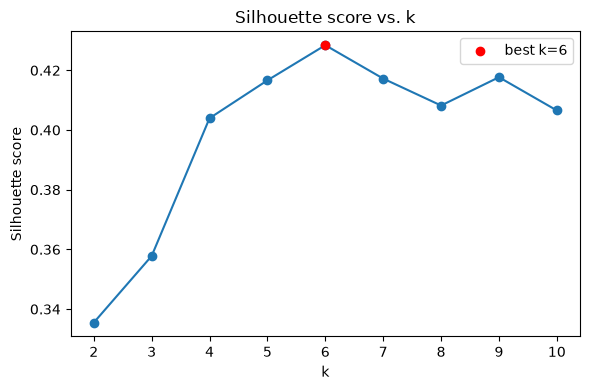

In [5]:
k_selection = hyperparams.select_k_by_silhouette(ds.X)
print("best k:", k_selection.best_k)
viz.plot_k_selection(k_selection.k_range, k_selection.scores, best_k=k_selection.best_k)
plt.show()

## DBSCAN eps selection

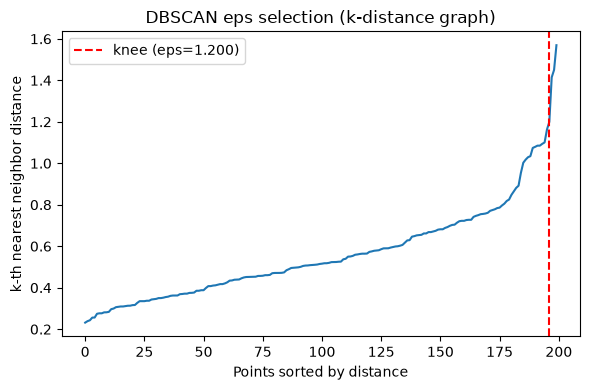

In [6]:
ms = hyperparams.default_min_samples(ds.X.shape[1])
kd = hyperparams.select_dbscan_eps(ds.X, min_samples=ms)
viz.plot_k_distance(kd.distances, kd.knee_idx, kd.eps_at_knee)
plt.show()

## Fit all 5 methods

In [7]:
results = clustering.run_all_methods(ds.X, None, spectral_affinity="rbf", k_selection=k_selection)
for name, r in results.items():
    print(f"{name:22s} params={r.params}  fit_seconds={r.fit_seconds:.3f}")

KMeans++               params={'n_clusters': 6}  fit_seconds=0.009
DBSCAN                 params={'eps': 0.5998282304001243, 'min_samples': 6}  fit_seconds=0.001
HDBSCAN                params={'min_cluster_size': 5}  fit_seconds=0.002
GMM                    params={'n_components': 6}  fit_seconds=0.008
Spectral Clustering    params={'n_clusters': 6, 'affinity': 'rbf'}  fit_seconds=0.013


## Metrics (internal only — no ground truth)

In [8]:
results_df = metrics.build_results_table(ds.name, ds.X, results, None)
display(results_df[METRIC_COLS])

,method,fit_seconds,n_clusters_found,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,KMeans++,0.008655,6,0.000,0.428417,0.825354,135.102104
1,DBSCAN,0.000885,5,0.175,0.195732,1.109134,30.885709
2,HDBSCAN,0.001659,6,0.375,0.556907,0.614832,195.690074
3,GMM,0.008459,6,0.000,0.399998,0.892656,113.698565
4,Spectral Clustering,0.012686,6,0.000,0.419177,0.817125,125.381444


## Cluster visualizations

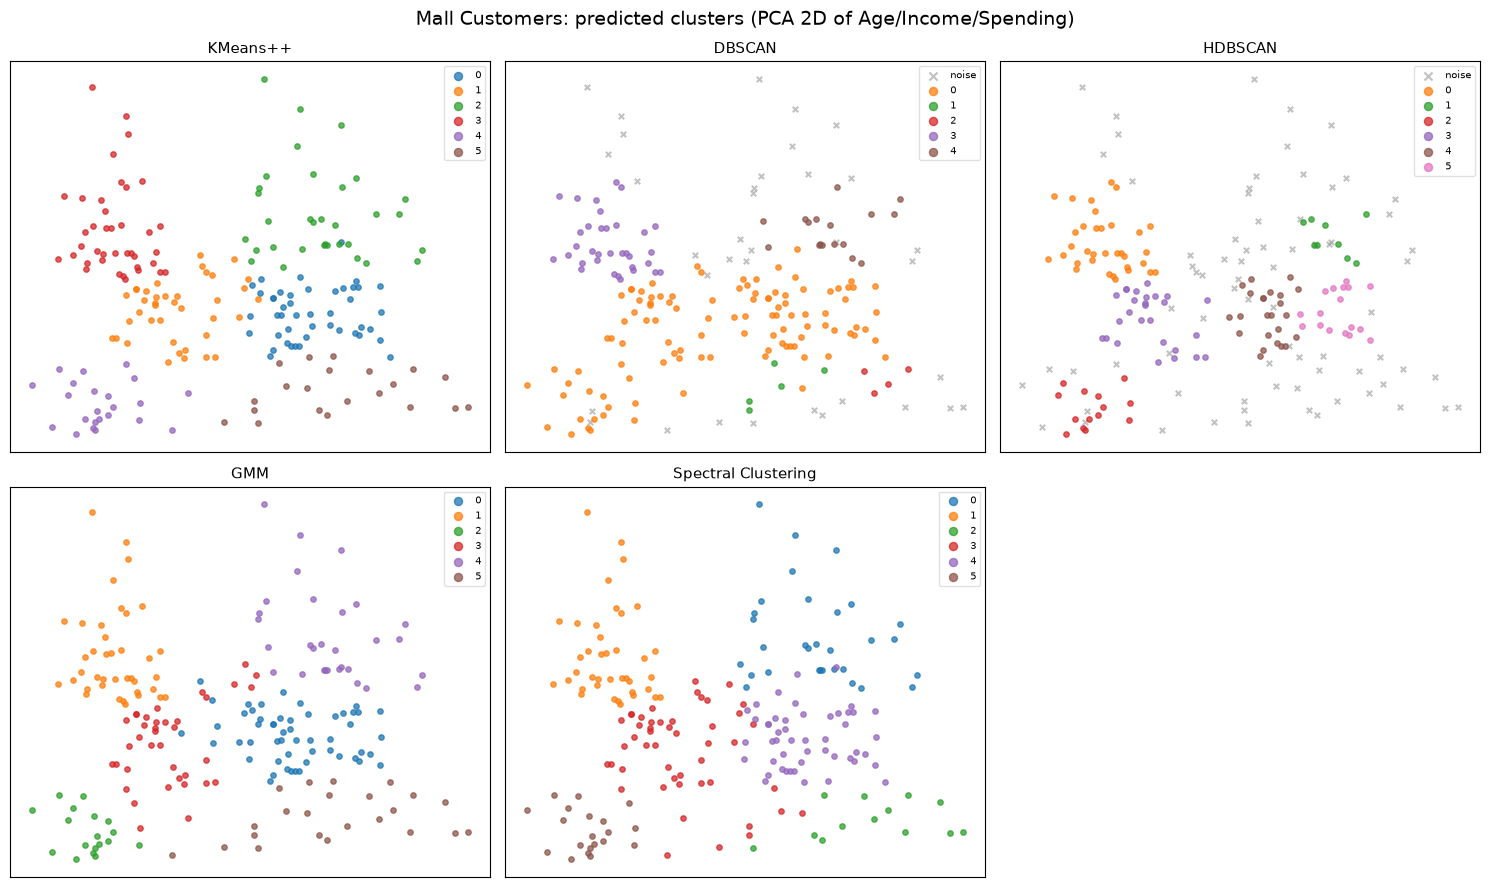

In [9]:
fig = viz.plot_cluster_grid(X_2d, results, y_true=None,
                             title="Mall Customers: predicted clusters (PCA 2D of Age/Income/Spending)")
plt.show()

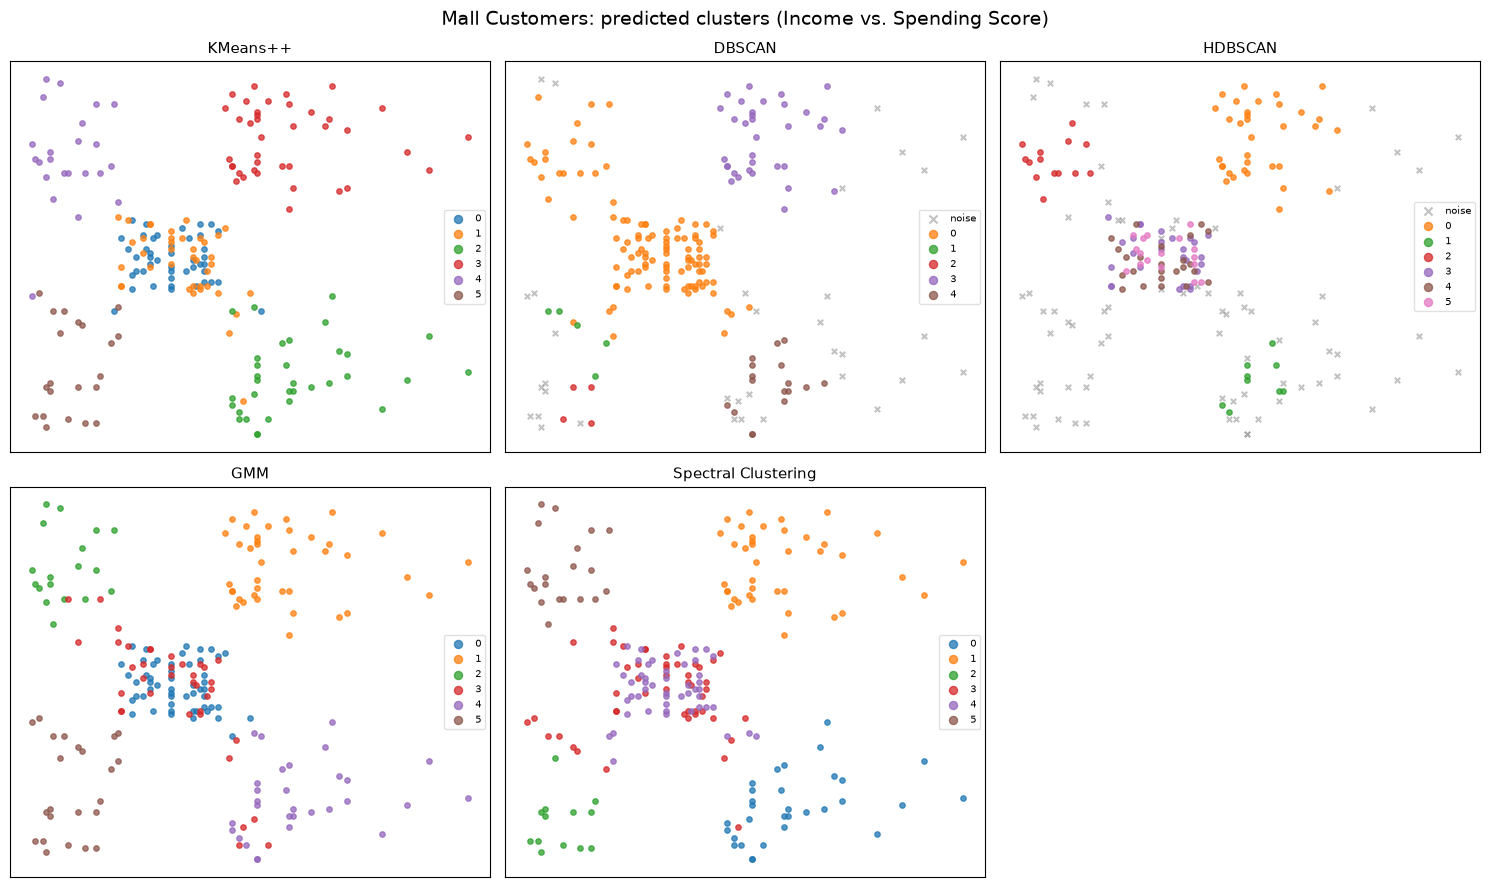

In [10]:
# Intuitive alternative view: Income vs. Spending Score directly (no PCA)
income_idx, spend_idx = ds.feature_names.index("Annual Income (k$)"), ds.feature_names.index("Spending Score (1-100)")
X_income_spend = ds.X[:, [income_idx, spend_idx]]
fig = viz.plot_cluster_grid(X_income_spend, results, y_true=None,
                             title="Mall Customers: predicted clusters (Income vs. Spending Score)")
plt.show()

## Discussion

- With no ground truth, only internal metrics (Silhouette, Davies-Bouldin,
  Calinski-Harabasz) can judge cluster quality here — external metrics
  (ARI/NMI/AMI/FMI) are reported as N/A for this dataset.
- The well-known "5-6 segment" structure of this dataset (e.g. high-income/
  low-spending, low-income/high-spending, etc.) is most visually obvious in
  the raw Income-vs-Spending-Score plane, which is why that view is included
  alongside the PCA-of-all-3-features view.
- Compare how consistently each method recovers similar segment boundaries;
  density-based methods (DBSCAN/HDBSCAN) may merge or split segments
  differently than the globular-cluster assumption of K-Means++/GMM/Spectral.